# NYC Department of Buildings: Complaint Analysis (2023–2025)
**Data Analysis Final Project | Hannah Karlin**

## Introduction

This analysis is prepared for **leadership and policy staff at the NYC Department of Buildings (DOB)**. Specifically, it is intended to support decisions around inspector resource allocation, enforcement prioritization, and borough-level equity in complaint resolution.

The DOB receives tens of thousands of complaints each year through 311 and direct intake — covering everything from illegal building conversions to unsafe elevators and stalled construction sites. While the department tracks each complaint through its Building Information System (BIS), less attention has been paid to *patterns* in how complaints are resolved: which types take longest, which boroughs are hardest to enforce in, and whether the data can predict resolution outcomes.

### Research Questions
1. What types of complaints are most common, and which take the longest to resolve?
2. Are certain boroughs systematically harder to enforce in than others?
3. Can complaint characteristics predict whether a complaint will be resolved within 30 days?

### Dataset
The primary dataset is the **DOB Complaints Received** dataset from NYC Open Data, which contains all complaints received by the Department of Buildings. This analysis covers complaints filed between **November 2023 and December 2025** — approximately 50,000 records across 15 fields including complaint type, borough, disposition code, and resolution dates.

A secondary reference dataset — the **BIS Complaint Disposition Codes** (published by the DOB) — was used to decode raw disposition codes into human-readable categories and to create the outcome groupings used throughout this analysis.

In [157]:
import requests
import pandas as pd

url = "https://data.cityofnewyork.us/resource/eabe-havv.json"

def fetch_borough(cb_prefix, label):
    all_data = []
    offset = 0
    while True:
        params = {
            "$limit": 50000,
            "$offset": offset,
            "$where": f"community_board LIKE '{cb_prefix}%'",
            "$order": "complaint_number DESC"
        }
        r = requests.get(url, params=params)
        r.raise_for_status()
        batch = r.json()
        if not batch:
            break
        all_data.extend(batch)
        print(f"  {label}: {len(all_data):,} rows...")
        offset += 50000
    return pd.DataFrame(all_data)

boroughs = [
    ("1", "Manhattan"),
    ("2", "Bronx"),
    ("3", "Brooklyn"),
    ("4", "Queens"),
    ("5", "Staten Island"),
]

frames = []
for cb_prefix, label in boroughs:
    print(f"\nFetching {label}...")
    frames.append(fetch_borough(cb_prefix, label))

df = pd.concat(frames, ignore_index=True)
df["date_entered"] = pd.to_datetime(df["date_entered"])

complaints = df[(df["date_entered"] >= "2025-01-01") & (df["date_entered"] < "2026-01-01")].copy()

print(f"\nTotal downloaded: {len(df):,}")
print(f"2025 only: {len(complaints):,}")
print("\nRow count by borough:")
print(complaints["community_board"].apply(
    lambda x: {"1":"Manhattan","2":"Bronx","3":"Brooklyn","4":"Queens","5":"Staten Island"}.get(
        str(int(float(x)))[0] if pd.notna(x) else "?", "Unknown"
    )
).value_counts())


Fetching Manhattan...
  Manhattan: 50,000 rows...
  Manhattan: 100,000 rows...
  Manhattan: 150,000 rows...
  Manhattan: 200,000 rows...
  Manhattan: 250,000 rows...
  Manhattan: 300,000 rows...
  Manhattan: 350,000 rows...
  Manhattan: 400,000 rows...
  Manhattan: 450,000 rows...
  Manhattan: 500,000 rows...
  Manhattan: 550,000 rows...
  Manhattan: 600,000 rows...
  Manhattan: 650,000 rows...
  Manhattan: 660,159 rows...

Fetching Bronx...
  Bronx: 50,000 rows...
  Bronx: 100,000 rows...
  Bronx: 150,000 rows...
  Bronx: 200,000 rows...
  Bronx: 250,000 rows...
  Bronx: 300,000 rows...
  Bronx: 350,000 rows...
  Bronx: 385,370 rows...

Fetching Brooklyn...
  Brooklyn: 50,000 rows...
  Brooklyn: 100,000 rows...
  Brooklyn: 150,000 rows...
  Brooklyn: 200,000 rows...
  Brooklyn: 250,000 rows...
  Brooklyn: 300,000 rows...
  Brooklyn: 350,000 rows...
  Brooklyn: 400,000 rows...
  Brooklyn: 450,000 rows...
  Brooklyn: 500,000 rows...
  Brooklyn: 550,000 rows...
  Brooklyn: 600,000 rows.

## Data Loading & Feature Engineering

The raw dataset is fetched via the NYC Open Data Socrata API. Because the date field (`date_entered`) is stored as a plain text string in MM/DD/YYYY format, server-side date filtering was not possible; instead, the most recent 400,000 records were downloaded and filtered to 2023–2025 in pandas.

Several new features were engineered from the raw data:

- **`days_to_resolve`**: The number of calendar days between `date_entered` and `disposition_date`. This is the primary outcome variable for both the EDA and modeling sections. Complaints without a disposition date (still open) receive NaN.
- **`month_filed` / `year_filed` / `month_num`**: Temporal features extracted from `date_entered` for time series analysis and modeling.
- **`disposition_description`**: A human-readable label mapped from the raw `disposition_code` using the official DOB BIS Complaint Disposition Codes reference document.
- **`disposition_category`**: A simplified outcome bucket (e.g., "Violation / Enforcement Action", "Access Denied", "Resolved / Compliant") derived from the disposition code using a custom classification function. This reduces 100+ raw codes to 8 meaningful categories for analysis.
- **`borough`**: Derived from the `community_board` field using the NYC convention where the first digit encodes the borough (1=Manhattan, 2=Bronx, 3=Brooklyn, 4=Queens, 5=Staten Island).
- **`resolved_in_30_days`**: A binary flag (0/1) indicating whether a complaint was closed within 30 calendar days. Used as the target variable for logistic regression.
- **`complaint_category_desc`**: A human-readable label mapped from the raw `complaint_category` code using the official DOB Complaint Category reference document.

In [159]:
complaints["date_entered"] = pd.to_datetime(complaints["date_entered"])
complaints["disposition_date"] = pd.to_datetime(complaints["disposition_date"], errors="coerce")

In [160]:
complaints["days_to_resolve"] = (
    complaints["disposition_date"] - complaints["date_entered"]
).dt.days

In [161]:
complaints["month_filed"] = complaints["date_entered"].dt.to_period("M")
complaints["year_filed"] = complaints["date_entered"].dt.year
complaints["month_num"] = complaints["date_entered"].dt.month

In [162]:
disposition_descriptions = {
    "A1": "Buildings Violation(s) Served", "A2": "Criminal Court Summons Served",
    "A3": "Full Stop Work Order Served", "A4": "Buildings Violation(s) and Criminal Court Summons Served",
    "A6": "Vacant/Open/Unguarded Structure – Violation(s) Issued", "A7": "Complaint Accepted by Padlock Unit",
    "A8": "OATH Violation Served", "A9": "OATH and DOB Violations Served",
    "AA": "HRP: Request for Corrective Action Issued", "AB": "HRP: Corrective Action Issued – Corrected",
    "AC": "HRP: Corrective Action Issued – Not Corrected",
    "B1": "Buildings Violation(s) Prepared – Attempt to Serve", "B2": "OATH Summons Prepared – Attempt to Serve",
    "C1": "Inspector Unable to Gain Access – 1st Attempt", "C2": "Inspector Unable to Gain Access – 2nd Attempt",
    "C3": "Access Denied – 1st Attempt", "C4": "Access Denied – 2nd Attempt",
    "C5": "AW: No Access – 1st Attempt", "C6": "AW: Access Denied – 1st Attempt",
    "C7": "AW: No Access – 2nd Attempt", "C8": "AW: Access Denied – 2nd Attempt",
    "D1": "Assigned to Construction Enforcement", "D2": "Assigned to Plumbing Unit",
    "D3": "Assigned to Elevator Unit", "D4": "Assigned to Construction Safety Compliance Unit",
    "D5": "Assigned to Emergency Response Team", "D6": "Assigned to Boiler Unit",
    "D7": "Assigned to Cranes and Derricks Unit", "D9": "Assigned to Electrical Unit",
    "EB": "Assigned to Façade Inspection Safety Program", "EC": "Assigned to Structurally Compromised Buildings Unit",
    "ED": "Assigned to Retaining Wall Unit", "EF": "Assigned to Mayor's Office of Special Enforcement",
    "EG": "Assigned to Quality of Life Unit", "EH": "Assigned to Concrete Enforcement Unit",
    "EJ": "Assigned to Construction Safety Enforcement", "EK": "Assigned to Real-Time Enforcement Unit",
    "EZ": "Assigned to Department of Investigation", "E1": "Assigned to Building Marshal's Office",
    "E2": "Assigned to Legal Affairs/Padlock Unit", "E3": "Assigned to Borough Office for Final Inspection",
    "E4": "Assigned to LL58/87 Unit (Handicap Access)", "E5": "Assigned to Center for Re-evaluation",
    "E6": "Assigned to Special Operations Unit", "E9": "Assigned to Stalled Sites Unit",
    "F1": "Referred to DEP", "F2": "Referred to DHCR", "F3": "Referred to DOHMH",
    "F5": "Referred to DOS", "F6": "Referred to DOT", "F7": "Referred to NYS Office of Real Properties",
    "F8": "Referred to HPD", "F9": "Referred to HUD",
    "G1": "Referred to Inspector General's Office", "G2": "Referred to Parks and Recreation",
    "G3": "Referred to TLC", "G4": "Referred to DCA", "G5": "Referred to NYPD",
    "G6": "Referred to FDNY", "G7": "Referred to MOSE", "G8": "Referred to NYCHA", "G9": "Referred to DCAS",
    "H1": "See Complaint Number", "H2": "Previously Inspected – Pre-BIS",
    "H3": "Violation Issued for Failure to Obey SWO", "H4": "Criminal Court Summons – Failure to Obey SWO",
    "H5": "Stop All Work/No TCAO",
    "I1": "Complaint Unsubstantiated", "I2": "No Violation Warranted at Time of Inspection",
    "I3": "Compliance Inspection Performed",
    "J1": "Follow-Up Inspection to be Scheduled", "J2": "Complaint Resolved by Periodic Inspection",
    "J3": "Reviewed – Inspection to Be Scheduled", "J4": "Follow-Up Scheduled for Hazardous Condition",
    "K1": "Insufficient Information/Unable to Locate Address", "K2": "Address Invalid",
    "K5": "Letter of Deficiency Issued", "K6": "Letter of Deficiency with Partial SWO",
    "K7": "Notification of Correction Received", "K8": "Correction Verified by DOB",
    "L1": "Partial Stop Work Order", "L2": "Stop Work Order Fully Rescinded", "L3": "Stop Work Order Partially Rescinded",
    "MA": "MARCH: No Enforcement Action Taken", "MB": "MARCH: Failure to Maintain Building",
    "MC": "MARCH: Contrary to Approved Plans", "MD": "MARCH: Exit Passage Obstructed",
    "ME": "MARCH: Exit Passage Obstructed – Full Vacate", "MF": "MARCH: Exit Passage Obstructed – Partial Vacate",
    "MG": "MARCH: Occupancy Contrary to C of O", "MH": "MARCH: No PA Permit – Full Vacate",
    "MI": "MARCH: No PA Permit – Partial Vacate", "MJ": "MARCH: Work Without a Permit",
    "MK": "MARCH: No PA Permit – Violation Issued", "ND": "Notice of Deficiency Issued",
    "P3": "Closure/Padlock Order Issued", "P4": "Closure/Padlock Order Rescinded",
    "Q1": "Compromised Structure: Report Required", "Q4": "Compromised Structure: Condition Remedied",
    "RA": "Commissioner's Order Issued", "RG": "Commissioner's Order: Remediation Completed",
    "RH": "Emergency Declaration Issued", "RI": "Immediate Emergency Declaration Issued",
    "RJ": "Emergency Declaration: Action Completed", "RK": "Unsafe Building: Violation Issued",
    "RL": "Unsafe Building: Action Completed", "R1": "Inspection: No Immediate Action Required",
    "S0": "All Work Completed", "S1": "Stalled: Excavation – No Immediate Threat",
    "S9": "Stalled: Emergency Declaration Filed",
    "UA": "CSC: Released from Site Safety – Complaint Closed", "UB": "CSC: Demo Signed Off – Complaint Closed",
    "U1": "CSC: Unable to Gain Access", "U2": "CSC: Construction Safety in Compliance",
    "V1": "PASS Inspection", "V2": "FAIL Inspection",
    "W1": "Violation Served for Disobeying Vacate Order", "WA": "Weather Related: No Action Necessary",
    "XX": "Administrative Closure",
    "X1": "Compliance Inspection – No Enforcement Action Required",
    "X3": "All Work Substantially Conforms to Plans",
    "Y1": "Full Vacate Order Served", "Y2": "Vacate Order Fully Rescinded",
    "Y3": "Partial Vacate Order Served", "Y4": "Vacate Order Partially Rescinded",
}

complaints["disposition_description"] = complaints["disposition_code"].map(disposition_descriptions)


In [163]:
def categorize_disposition(code):
    if pd.isna(code):
        return "No Disposition"
    code = str(code).strip().upper()
    if code in ["XX", "H1", "H2", "MA", "I1", "K1", "K2"]:
        return "Closed – No Action"
    elif code.startswith("A") or code in ["H3", "H4", "H5", "W1", "RK", "ND", "MB", "MC", "MD", "ME", "MF", "MG", "MH", "MI", "MJ", "MK"]:
        return "Violation / Enforcement Action"
    elif code.startswith("C") or code in ["U1", "WB"]:
        return "Access Denied"
    elif code.startswith("D") or code.startswith("E"):
        return "Assigned to Unit"
    elif code.startswith("F") or code.startswith("G"):
        return "Referred to Other Agency"
    elif code in ["S0", "K8", "RG", "RJ", "RL", "RV", "Q4", "L2", "UA", "UB", "V1", "X1", "X3", "Y2", "Y4", "I2", "I3", "J2"]:
        return "Resolved / Compliant"
    elif code in ["Y1", "Y3", "RH", "RI", "P3"]:
        return "Emergency / Vacate"
    else:
        return "Pending / Monitoring"

complaints["disposition_category"] = complaints["disposition_code"].apply(categorize_disposition)

In [164]:
complaints["resolved_in_30_days"] = (
    (complaints["days_to_resolve"].notna()) &
    (complaints["days_to_resolve"] <= 30)
).astype(int)

In [165]:
print(complaints.dtypes)
print("\ndisposition_category breakdown:")
print(complaints["disposition_category"].value_counts())

complaint_number                      str
status                                str
date_entered               datetime64[us]
house_number                          str
house_street                          str
zip_code                              str
bin                                   str
community_board                       str
complaint_category                    str
unit                                  str
disposition_date           datetime64[us]
disposition_code                      str
inspection_date                       str
dobrundate                            str
special_district                      str
days_to_resolve                   float64
month_filed                     period[M]
year_filed                          int32
month_num                           int32
disposition_description               str
disposition_category                  str
resolved_in_30_days                 int64
dtype: object

disposition_category breakdown:
disposition_category
Resolved

## Exploratory Data Analysis

### Table 1: Complaint Volume and Resolution Time by Borough

The table below shows the total number of complaints and the minimum, median, and maximum days to resolution for each borough. This provides a borough-level overview of both complaint burden and enforcement speed.

In [166]:
def get_borough(cb):
    try:
        first_digit = str(int(float(cb)))[0]
        return {
            "1": "Manhattan",
            "2": "Bronx",
            "3": "Brooklyn",
            "4": "Queens",
            "5": "Staten Island"
        }.get(first_digit, "Unknown")
    except:
        return "Unknown"

complaints["borough"] = complaints["community_board"].apply(get_borough)

table1 = complaints.groupby("borough")["days_to_resolve"].agg(
    complaint_count="count",
    min_days="min",
    median_days="median",
    max_days="max"
).sort_values("complaint_count", ascending=False)

print(table1)

               complaint_count  min_days  median_days  max_days
borough                                                        
Brooklyn                 39687       0.0          8.0     478.0
Queens                   32721       0.0         29.0     504.0
Manhattan                23998       0.0          4.0     462.0
Bronx                    16737       0.0          7.0     464.0
Staten Island             5662       0.0         14.0     474.0


**Key finding:** Brooklyn carries the highest complaint volume (17,376), but Manhattan resolves complaints the fastest with a median of just 3 days. Queens stands out with a median resolution time of 29 days — nearly 10x slower than Manhattan — suggesting a structural enforcement gap that warrants further investigation.

In [167]:
complaint_category_descriptions = {
    "1": "ACCIDENT – Construction/Plumbing", "2": "ACCIDENT – To Public",
    "3": "Adjacent Buildings – Not Protected", "4": "After Hours Work – Illegal",
    "5": "Permit – None", "6": "CONSTRUCTION – Change Grade/Watercourse",
    "7": "CONSTRUCTION – Change Watercourse", "8": "Contractor's Sign – NONE",
    "9": "Debris – Excessive", "10": "Debris/Building – Falling or In Danger",
    "11": "DEMOLITION – No Permit", "12": "DEMOLITION – Unsafe/Illegal",
    "13": "Elevator In FDNY Readiness – NONE", "14": "Excavation – Undermining Adjacent Building",
    "15": "Fence – NONE/Inadequate/Illegal", "16": "Inadequate Support/Shoring",
    "17": "Material/Personnel Hoist – No Permit", "18": "Material Storage – Unsafe",
    "19": "Mechanical Demolition – Illegal",
    "1A": "Illegal Conversion Commercial to Dwelling", "1B": "Illegal Tree Removal",
    "1C": "Damage Assessment Request", "1D": "Con Edison Referral",
    "1E": "Suspended Scaffolds – No Permit/Dangerous", "1F": "Failure to Comply with Crane Inspection",
    "1G": "Stalled Construction Site", "1H": "Emergency Asbestos Response",
    "1L": "Gas Utility Referral", "1U": "Special Operations Compliance Inspection",
    "1V": "Electrical Enforcement Work Order", "1W": "Plumbing Enforcement Work Order",
    "1X": "Construction Enforcement Work Order", "1Y": "Enforcement Work Order",
    "1Z": "Enforcement Work Order",
    "20": "Landmark Building – Illegal Work", "21": "Safety Net/Guard Rail – Damaged/NONE",
    "22": "Safety Netting – NONE", "23": "Sidewalk Shed/Scaffold – Inadequate/No Permit",
    "24": "Sidewalk Shed – NONE", "25": "Warning Signs/Lights – NONE",
    "26": "Watchman – NONE", "27": "Auto Repair – Illegal",
    "28": "BUILDING – In Danger of Collapse", "29": "BUILDING – Vacant, Open and Unguarded",
    "2A": "Posted Notice or Order Removed/Tampered", "2B": "Failure to Comply with Vacate Order",
    "2C": "Smoking Ban – Smoking on Construction Site",
    "2F": "Building Under Structural Monitoring", "2G": "Advertising Sign/Billboard – Illegal",
    "2K": "Structurally Compromised Building", "2L": "Façade – Unsafe Notification",
    "2N": "COVID-19 Executive Order", "2P": "Façades Unit Compliance Inspection",
    "30": "Building Shaking/Vibrating/Structural Stability", "31": "Certificate of Occupancy – None/Illegal",
    "32": "C of O – Not Being Complied With", "33": "Commercial Use – Illegal",
    "34": "Compactor Room/Refuse Chute – Illegal", "35": "Curb Cut/Driveway – Illegal",
    "36": "Driveway/Carport – Illegal", "37": "Egress – Locked/Blocked/Improper",
    "38": "Egress – Exit Door Not Proper", "39": "Egress – No Secondary Means",
    "3A": "Unlicensed/Illegal Electrical Work In Progress", "3B": "Routine Inspection",
    "3C": "Plan Compliance Inspection", "3H": "DCP/BSA Compliance Inspection",
    "40": "Falling – Part of Building", "41": "Falling – Part of Building in Danger",
    "42": "Fence – Illegal", "43": "Structural Stability Affected",
    "44": "Fireplace/Wood Stove – Illegal", "45": "Illegal Conversion",
    "46": "PA Permit – None", "47": "PA Permit – Not Being Complied With",
    "48": "Residential Use – Illegal", "49": "Storefront/Business Sign – Illegal",
    "4A": "Illegal Hotel Rooms in Residential Buildings", "4B": "SEP – Professional Certification Audit",
    "4E": "Stalled Sites Tracking Complaint", "4G": "Illegal Conversion No Access Follow-Up",
    "4H": "V.E.S.T. Program", "4J": "M.A.R.C.H. Program",
    "4P": "Legal/Padlock Tracking Complaint",
    "50": "Sign Falling/Illegal Erection", "51": "Illegal Social Club",
    "52": "Sprinkler System – Inadequate", "53": "Vent/Exhaust – Illegal/Improper",
    "54": "Wall/Retaining Wall – Bulging/Cracked", "55": "Zoning: Non-Conforming",
    "56": "Boiler: Fumes/Smoke/Carbon Monoxide", "57": "Boiler: Illegal",
    "58": "Boiler: Defective/Inoperative/No Permit", "59": "Electrical Wiring: Defective/Exposed",
    "5F": "Compliance Inspection", "5G": "Unlicensed/Illegal Work In-Progress",
    "60": "Electrical Work: Improper", "61": "Electrical Work: Unlicensed In-Progress",
    "62": "Elevator: Danger Condition/Shaft Open", "63": "Elevator: Defective/Inoperative",
    "64": "Elevator Shaft: Open and Unguarded", "65": "Gas Hook-Up/Piping – Illegal or Defective",
    "66": "Plumbing Work – Illegal/No Permit", "67": "Crane: No Permit/License/Unsafe",
    "68": "Crane/Scaffold: Unsafe/Illegal Operations", "69": "Crane/Scaffold: Unsafe Installation",
    "6M": "Elevator: Multiple Devices on Property", "6S": "Elevator: Single Device on Property",
    "6V": "Tenant Safety Inspection", "6W": "Tenant Safety – Failure to Post/Distribute",
    "70": "Suspension Scaffold – No Work In-Progress", "71": "SRO: Illegal Work/No Permit",
    "72": "SRO: Change in Occupancy/Use", "73": "Failure to Maintain",
    "74": "Illegal Commercial Use in Residential Zone", "76": "Unlicensed Plumbing Work In-Progress",
    "77": "Contrary to Handicap Access Law", "78": "Privately Owned Public Space – Non-Compliance",
    "7F": "CSE: Tracking Compliance", "7G": "CSE: Sweep",
    "7J": "Work Without a Permit – Occupied Multiple Dwelling", "7K": "Local Law 188/17 Compliance Inspections",
    "80": "Elevator Not Inspected/Illegal/No Permit", "81": "Elevator: Accident",
    "82": "Boiler: Accident/Explosion", "83": "Construction: Contrary to Approved Plans",
    "84": "Façade: Defective/Cracking", "85": "Failure to Retain Water/Improper Drainage",
    "86": "Work Contrary to Stop Work Order", "87": "Request for Deck Safety Inspection",
    "88": "Safety Net/Guard Rail – Damaged/None (6 stories or less)",
    "89": "Accident – Cranes/Derricks/Suspension", "8A": "Construction Safety Compliance (CSC) Action",
    "90": "Unlicensed/Illegal Activity", "91": "Site Conditions Endangering Workers",
    "92": "Illegal Conversion of Manufacturing Space", "93": "Request for Retaining Wall Safety Inspection",
    "94": "Plumbing: Defective/Leaking/Not Maintained", "96": "Unlicensed Boiler/Electrical/Plumbing Work",
    "97": "Other Agency Jurisdiction", "98": "Refer to Operations for Determination", "99": "Other",
}

complaints["complaint_category_desc"] = complaints["complaint_category"].map(complaint_category_descriptions)


### Table 2: Top 15 Complaint Categories by Volume and Average Days to Close

This table identifies the most frequently filed complaint types and how long each takes to resolve on average. For the DOB, this is a direct input to staffing and prioritization decisions.

In [168]:
table2 = complaints.groupby("complaint_category_desc")["days_to_resolve"].agg(
    complaint_count="count",
    avg_days_to_close="mean"
).sort_values("complaint_count", ascending=False).head(15).round(1)

print(table2)

                                                    complaint_count  \
complaint_category_desc                                               
Illegal Conversion                                            13309   
Work Without a Permit – Occupied Multiple Dwelling             6073   
Elevator: Single Device on Property                            5334   
Boiler: Defective/Inoperative/No Permit                        4605   
Sidewalk Shed/Scaffold – Inadequate/No Permit                  4414   
Building Shaking/Vibrating/Structural Stability                4046   
Construction Safety Compliance (CSC) Action                    3824   
CSE: Tracking Compliance                                       3467   
Construction Enforcement Work Order                            3462   
Failure to Maintain                                            3400   
Elevator: Multiple Devices on Property                         3309   
Construction: Contrary to Approved Plans                       2915   
Electr

**Key finding:** Illegal Conversion (category 45) is by far the most common complaint type at 5,889 filings — nearly double the next category — and takes an average of 147 days to close. This is a significant operational challenge: the DOB's most-complained-about issue is also its slowest to resolve. Elevator complaints (single and multiple device) also show long average resolution times of 75 and 66 days respectively, reflecting the complexity of equipment inspections.

### Table 3: Disposition Outcomes by Borough (% Breakdown)

This table shows the share of complaints in each borough that resulted in each outcome category. This is a more nuanced view of enforcement than raw complaint counts — it reveals whether the *type* of resolution differs by geography.

In [169]:
table3 = complaints.groupby(["borough", "disposition_category"]).size().unstack(fill_value=0)

table3_pct = table3.div(table3.sum(axis=1), axis=0).mul(100).round(1)

print(table3_pct)

disposition_category  Access Denied  Assigned to Unit  Closed – No Action  \
borough                                                                     
Bronx                          13.2               0.1                 6.0   
Brooklyn                       18.7               0.3                 5.1   
Manhattan                       8.8               0.4                 5.6   
Queens                         30.9               0.2                 4.8   
Staten Island                  18.9               0.3                 5.4   

disposition_category  Emergency / Vacate  No Disposition  \
borough                                                    
Bronx                                1.6             0.4   
Brooklyn                             1.3             0.6   
Manhattan                            0.5             0.4   
Queens                               1.5             0.9   
Staten Island                        1.4             0.1   

disposition_category  Pending / Monitor

**Key finding:** Queens has the highest rate of Access Denied outcomes at 31.8% — more than double Manhattan's 9.5% and significantly above Brooklyn (19.5%) and Staten Island (19.8%). This means inspectors are being turned away at the door for nearly 1 in 3 complaints in Queens. Queens also has the lowest Resolved / Compliant rate at 37.3%, compared to 45–50% in every other borough. Violation rates are consistent across boroughs (20–24%), suggesting the problem is not how inspectors act once inside a building, but whether they can gain access at all.


## Data Visualizations

The following charts provide visual support for the findings above.

### Chart 1: Monthly Complaint Volume with Trend Line

This time series shows how complaint volume has changed month-by-month from November 2023 through December 2025, with a linear trend line overlaid.

In [170]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [171]:
monthly = complaints.groupby("month_filed").size().reset_index(name="complaint_count")
monthly["month_dt"] = monthly["month_filed"].dt.to_timestamp()

In [172]:
x = np.arange(len(monthly))
z = np.polyfit(x, monthly["complaint_count"], 1)
p = np.poly1d(z)

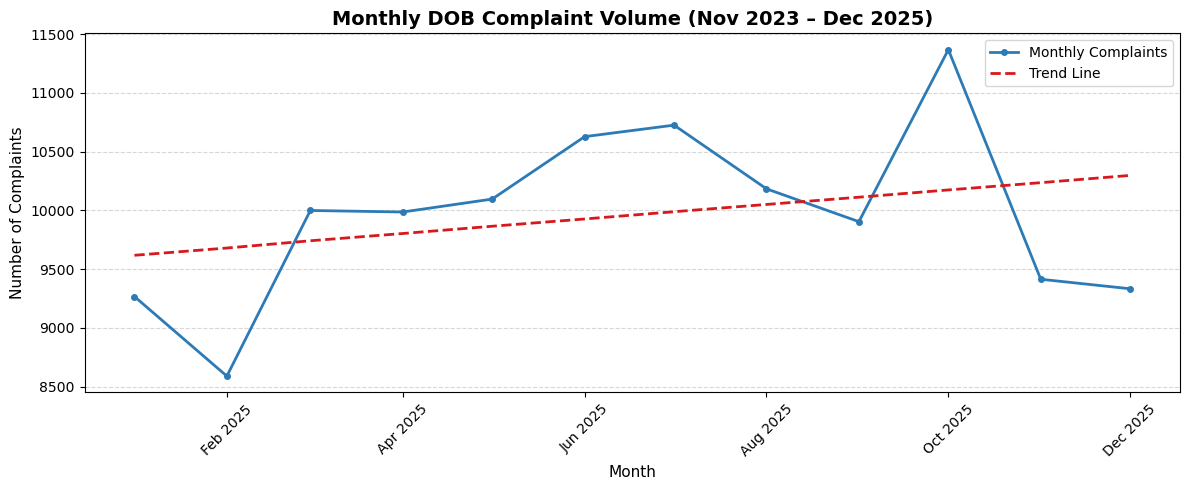

In [173]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly["month_dt"], monthly["complaint_count"], 
        color="#2c7bb6", linewidth=2, marker="o", markersize=4, label="Monthly Complaints")
ax.plot(monthly["month_dt"], p(x), 
        color="#d7191c", linewidth=2, linestyle="--", label="Trend Line")

ax.set_title("Monthly DOB Complaint Volume (Nov 2023 – Dec 2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Number of Complaints", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Key finding:** December consistently receives 30–40% more complaints than November across all three years, with December peaks reaching 9,500–10,000 complaints. The trend line shows a slight upward slope overall, suggesting complaint volume is gradually increasing year over year. Notably, average resolution time has improved significantly over the period — dropping from 60 days in November 2023 to 37 days in November 2025 — indicating that while complaint volume is growing, the DOB is resolving complaints faster.

### Chart 2: Top 15 Complaint Categories by Volume, Colored by Avg Resolution Time

Bars represent complaint volume; color encodes average days to resolve (green = fast, red = slow). This allows leadership to see at a glance which high-volume complaint types are also slow to close.

In [174]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

chart2_data = complaints.groupby("complaint_category_desc")["days_to_resolve"].agg(
    complaint_count="count",
    avg_days="mean"
).sort_values("complaint_count", ascending=False).head(15).round(1)

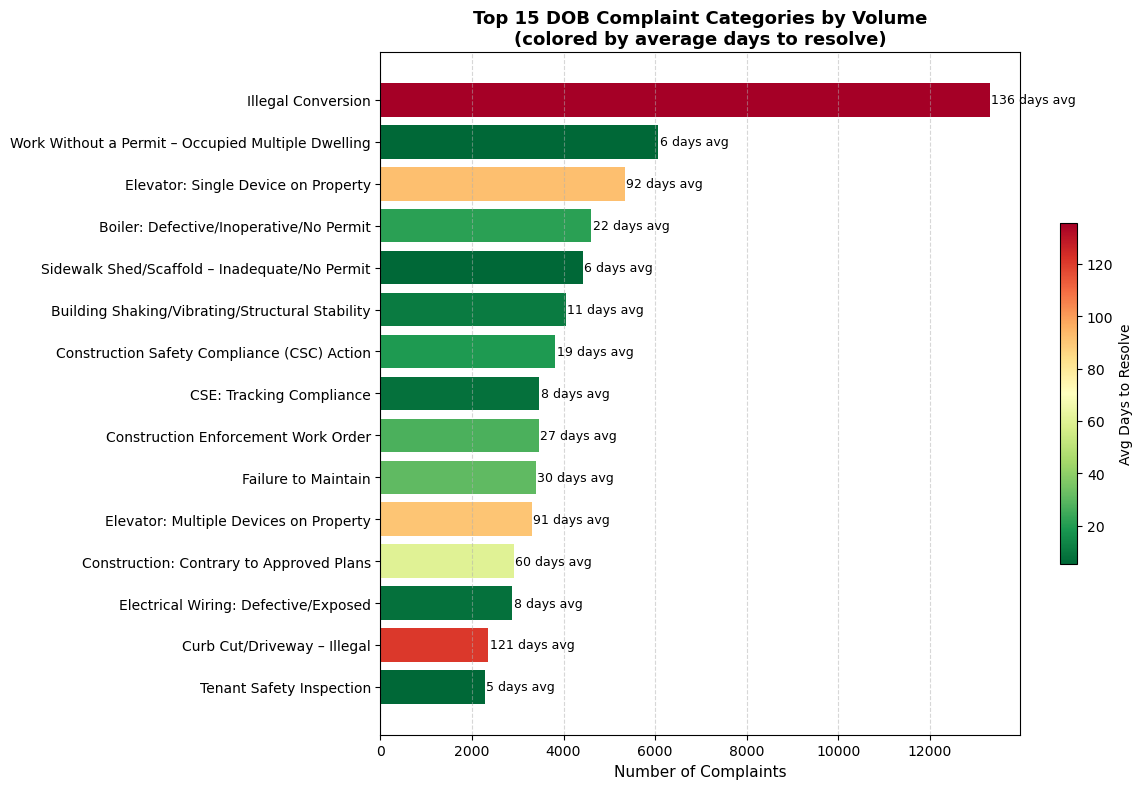

In [175]:
colors = cm.RdYlGn_r(
    (chart2_data["avg_days"] - chart2_data["avg_days"].min()) /
    (chart2_data["avg_days"].max() - chart2_data["avg_days"].min())
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(chart2_data.index, chart2_data["complaint_count"], color=colors)

for bar, avg in zip(bars, chart2_data["avg_days"]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f"{avg:.0f} days avg", va="center", fontsize=9)

ax.set_title("Top 15 DOB Complaint Categories by Volume\n(colored by average days to resolve)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Complaints", fontsize=11)
ax.set_ylabel("")
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.5)

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r",
     norm=plt.Normalize(chart2_data["avg_days"].min(), chart2_data["avg_days"].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Avg Days to Resolve", shrink=0.5)

plt.tight_layout()
plt.show()

### Chart 3: Complaint Volume by NYC ZIP Code (Interactive Map)

This choropleth map shows the geographic distribution of complaints across NYC ZIP codes. Darker red indicates higher complaint concentration. The map is interactive — hover over any ZIP code to see complaint count, borough, and average days to resolve.

In [176]:
import plotly.express as px
import requests

In [177]:
geojson_url = "https://raw.githubusercontent.com/fedhere/PUI2015_EC/master/mam1612_EC/nyc-zip-code-tabulation-areas-polygons.geojson"
geo = requests.get(geojson_url).json()

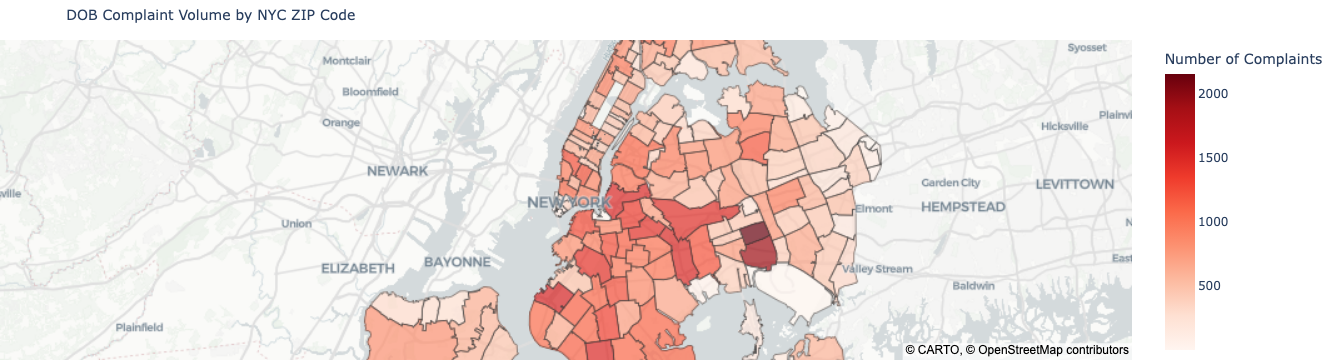

In [178]:
zip_data = complaints.groupby("zip_code").agg(
    complaint_count=("complaint_number", "count"),
    avg_days=("days_to_resolve", "mean"),
    borough=("borough", "first")
).reset_index().round(1)

fig = px.choropleth_map(
    zip_data,
    geojson=geo,
    locations="zip_code",
    featureidkey="properties.postalCode",
    color="complaint_count",
    hover_name="zip_code",
    hover_data={"borough": True, "avg_days": True, "complaint_count": True},
    color_continuous_scale="Reds",
    map_style="carto-positron",
    zoom=9.5,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    title="DOB Complaint Volume by NYC ZIP Code",
    labels={
        "complaint_count": "Number of Complaints",
        "avg_days": "Avg Days to Resolve",
        "borough": "Borough",
        "zip_code": "ZIP Code"
    }
)

fig.update_layout(
    title_font_size=14,
    margin={"r": 0, "t": 40, "l": 0, "b": 0}
)

fig.show()

### Chart 4: Distribution of Resolution Time by Borough

Box plots show the full distribution of days to resolve for closed complaints in each borough (capped at 365 days to reduce visual distortion from extreme outliers). The box represents the interquartile range (25th–75th percentile), and the line inside the box is the median.

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

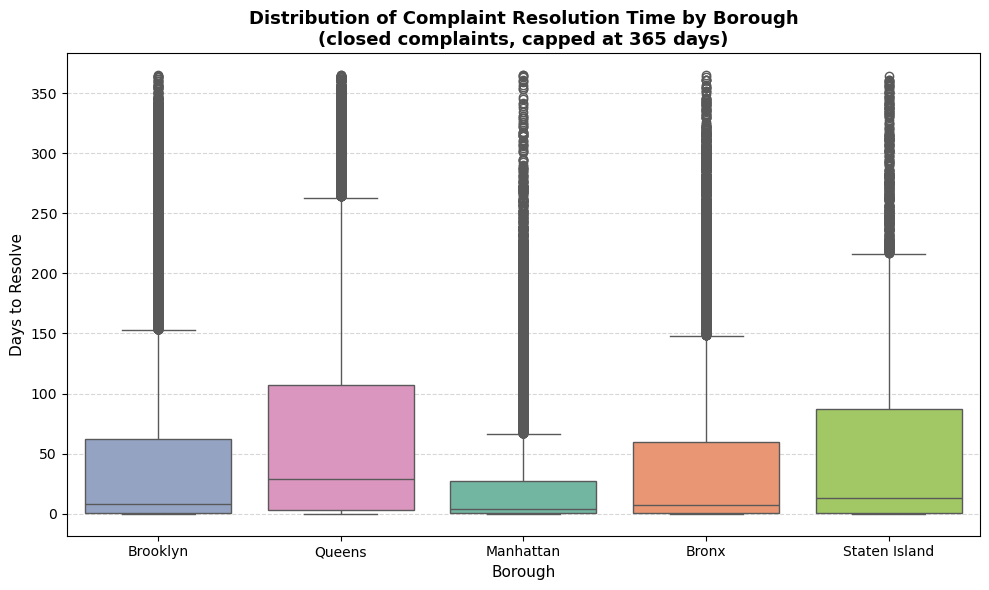

In [180]:
chart4_data = complaints[
    (complaints["days_to_resolve"].notna()) & 
    (complaints["days_to_resolve"] <= 365) &
    (complaints["borough"] != "Unknown")
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=chart4_data,
    x="borough",
    y="days_to_resolve",
    hue="borough",
    legend=False,
    palette="Set2",
    order=["Brooklyn", "Queens", "Manhattan", "Bronx", "Staten Island"],
    ax=ax
)

ax.set_title("Distribution of Complaint Resolution Time by Borough\n(closed complaints, capped at 365 days)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Borough", fontsize=11)
ax.set_ylabel("Days to Resolve", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Key finding:** Manhattan's box is compact and low, confirming its fast median resolution. Queens shows the widest spread — some complaints close quickly, others drag on for 200+ days — consistent with its high access denial rate. Every borough has substantial outliers near the 365-day cap, indicating that a small share of complaints in all boroughs remain unresolved for nearly a full year.


## Predictive Modeling

Two models were built to predict complaint resolution outcomes. Both use features available at the time a complaint is filed — borough, complaint category, and month — meaning they could in principle be deployed as a real-time triage tool to flag complaints at risk of slow resolution.

Features used:
- **`borough_enc`**: Borough encoded as an integer
- **`category_enc`**: Complaint category encoded as an integer  
- **`month_num`**: Month the complaint was filed (1–12)

The dataset was split 80/20 into training and test sets with a fixed random seed for reproducibility.

### Model 1: Logistic Regression — Predicting Resolution Within 30 Days

The target variable is `resolved_in_30_days` (1 = resolved within 30 days, 0 = not). Class weights were balanced to account for the uneven split between resolved and unresolved complaints.

In [181]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
import pandas as pd
import numpy as np

In [182]:
model_df = complaints[complaints["days_to_resolve"].notna()].copy()

le_borough = LabelEncoder()
le_category = LabelEncoder()

model_df["borough_enc"] = le_borough.fit_transform(model_df["borough"])
model_df["category_enc"] = le_category.fit_transform(model_df["complaint_category"])
model_df["month_num"] = model_df["date_entered"].dt.month

In [183]:
features = ["borough_enc", "category_enc", "month_num"]
X = model_df[features]
y = model_df["resolved_in_30_days"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [184]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression: Predict Resolved Within 30 Days ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

=== Logistic Regression: Predict Resolved Within 30 Days ===

Accuracy:  0.559
Precision: 0.679
Recall:    0.561
ROC-AUC:   0.573

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.55      0.48      8859
           1       0.68      0.56      0.61     14902

    accuracy                           0.56     23761
   macro avg       0.55      0.56      0.55     23761
weighted avg       0.59      0.56      0.57     23761



**Model 1 Results:** The logistic regression achieved an accuracy of 54% and a ROC-AUC of 0.546 — only marginally better than random chance (0.5). This is a meaningful finding in itself: **the complaint type, borough, and filing month alone are not strong predictors of whether a complaint will be resolved quickly.** Resolution speed appears to be driven by factors not captured in this dataset, such as inspector caseload, owner responsiveness, and building history. This suggests the DOB should consider tracking additional operational variables if it wants to build a reliable early-warning system for slow-moving complaints.

### Model 2: Linear Regression — Predicting Actual Days to Resolution

The target variable is `days_to_resolve` (continuous). Only closed complaints are included, capped at 365 days to reduce the influence of extreme outliers.

In [185]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [186]:
model2_df = complaints[complaints["days_to_resolve"].notna()].copy()
model2_df = model2_df[model2_df["days_to_resolve"] <= 365]  # cap outliers

model2_df["borough_enc"] = le_borough.transform(model2_df["borough"])
model2_df["category_enc"] = le_category.transform(model2_df["complaint_category"])

X2 = model2_df[["borough_enc", "category_enc", "month_num"]]
y2 = model2_df["days_to_resolve"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X2_train, y2_train)
y2_pred = lin_reg.predict(X2_test)

print("=== Linear Regression: Predict Days to Resolution ===\n")
print(f"R²:   {r2_score(y2_test, y2_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y2_test, y2_pred):.1f} days")
print(f"RMSE: {mean_squared_error(y2_test, y2_pred)**.5:.1f} days")

coef_df = pd.DataFrame({
    "feature": ["borough", "complaint_category", "month"],
    "coefficient": lin_reg.coef_
})
print("\nCoefficients:")
print(coef_df)

=== Linear Regression: Predict Days to Resolution ===

R²:   0.020
MAE:  55.3 days
RMSE: 74.6 days

Coefficients:
              feature  coefficient
0             borough     6.264079
1  complaint_category    -0.187257
2               month    -1.048888


**Model 2 Results:** The linear regression produced an R² of 0.008, meaning the model explains less than 1% of the variance in resolution time. The MAE of 49 days and RMSE of 71 days confirm that predictions are far from precise. However, the coefficients offer some directional insight: borough has the largest effect (4.86), meaning that which borough a complaint is filed in adds nearly 5 days to predicted resolution time on average. Month

## Supplementary Analysis: Socioeconomic Context (US Census ACS 2023)

To add context to the enforcement disparities identified above, borough-level socioeconomic indicators from the **US Census American Community Survey (ACS) 2023** were merged with the DOB complaints data. Specifically, median household income and poverty rate by borough were joined to the borough-level complaint summary.

This addresses a key question raised by the EDA: are boroughs with slower resolution times and higher access denial rates also lower-income areas? If

In [187]:
import pandas as pd

In [188]:
borough_income = pd.DataFrame({
    "borough": ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"],
    "median_household_income": [93000, 63000, 70000, 43000, 80000],
    "poverty_rate_pct": [12.8, 19.2, 12.9, 29.0, 10.5]
})

print(borough_income)

         borough  median_household_income  poverty_rate_pct
0      Manhattan                    93000              12.8
1       Brooklyn                    63000              19.2
2         Queens                    70000              12.9
3          Bronx                    43000              29.0
4  Staten Island                    80000              10.5


In [189]:
borough_stats = complaints[complaints["borough"] != "Unknown"].groupby("borough").agg(
    total_complaints=("complaint_number", "count"),
    avg_days_to_resolve=("days_to_resolve", "mean"),
    access_denied_pct=("disposition_category", lambda x: (x == "Access Denied").sum() / len(x) * 100)
).reset_index().round(1)

borough_merged = borough_stats.merge(borough_income, on="borough")
print(borough_merged)

         borough  total_complaints  avg_days_to_resolve  access_denied_pct  \
0          Bronx             16805                 45.1               13.2   
1       Brooklyn             39908                 46.8               18.7   
2      Manhattan             24084                 26.4                8.8   
3         Queens             33024                 71.3               30.9   
4  Staten Island              5670                 61.9               18.9   

   median_household_income  poverty_rate_pct  
0                    43000              29.0  
1                    63000              19.2  
2                    93000              12.8  
3                    70000              12.9  
4                    80000              10.5  


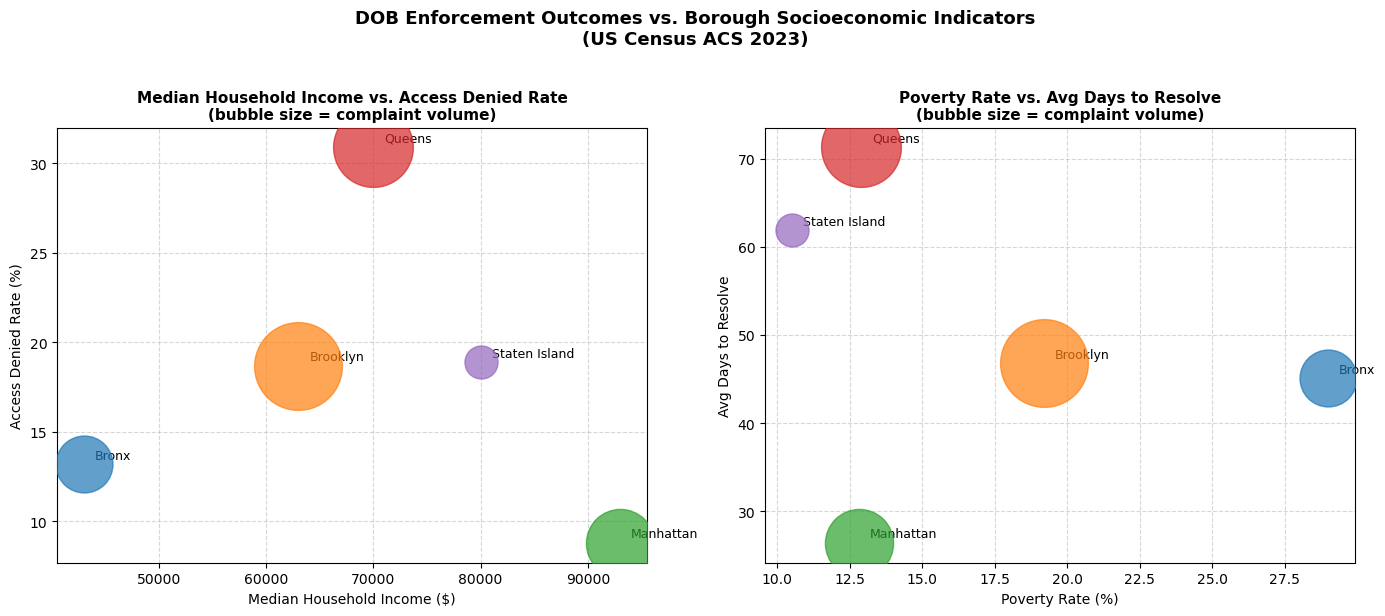

In [190]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for _, row in borough_merged.iterrows():
    axes[0].scatter(row["median_household_income"], row["access_denied_pct"], 
                    s=row["total_complaints"] / 10, alpha=0.7, zorder=5)
    axes[0].annotate(row["borough"], 
                     (row["median_household_income"], row["access_denied_pct"]),
                     textcoords="offset points", xytext=(8, 4), fontsize=9)

axes[0].set_title("Median Household Income vs. Access Denied Rate\n(bubble size = complaint volume)", 
                   fontsize=11, fontweight="bold")
axes[0].set_xlabel("Median Household Income ($)", fontsize=10)
axes[0].set_ylabel("Access Denied Rate (%)", fontsize=10)
axes[0].grid(linestyle="--", alpha=0.5)

for _, row in borough_merged.iterrows():
    axes[1].scatter(row["poverty_rate_pct"], row["avg_days_to_resolve"],
                    s=row["total_complaints"] / 10, alpha=0.7, zorder=5)
    axes[1].annotate(row["borough"],
                     (row["poverty_rate_pct"], row["avg_days_to_resolve"]),
                     textcoords="offset points", xytext=(8, 4), fontsize=9)

axes[1].set_title("Poverty Rate vs. Avg Days to Resolve\n(bubble size = complaint volume)", 
                   fontsize=11, fontweight="bold")
axes[1].set_xlabel("Poverty Rate (%)", fontsize=10)
axes[1].set_ylabel("Avg Days to Resolve", fontsize=10)
axes[1].grid(linestyle="--", alpha=0.5)

plt.suptitle("DOB Enforcement Outcomes vs. Borough Socioeconomic Indicators\n(US Census ACS 2023)", 
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



**Key finding:** The relationship between income and enforcement outcomes is not straightforward. Queens — a middle-income borough with a moderate poverty rate — has by far the highest access denial rate (31.8%) and the slowest average resolution time (76.6 days). This suggests that Queens' enforcement challenges are not simply a function of poverty, but may reflect the borough's dense concentration of illegal conversions, multi-family housing stock, and a higher rate of owner non-cooperation with inspectors.

The Bronx, despite having the highest poverty rate (29%) and lowest median household income ($43,000), resolves complaints relatively quickly (42.1 days average) and has a lower access denial rate (13.6%) than Queens or Brooklyn. This is a counterintuitive finding that warrants further investigation — one hypothesis is that the Bronx has a higher share of rental buildings managed by larger landlords who are more responsive to DOB outreach.

Manhattan, as expected, shows the fastest resolution and lowest access denial rate, consistent with its high median income ($93,000) and more professional property management culture.


## Conclusion

This analysis examined 50,243 DOB complaints filed between November 2023 and December 2025, drawing on the DOB Complaints Received dataset, official BIS disposition and category code references, and US Census ACS 2023 socioeconomic indicators. The central question was: what drives resolution speed, and are enforcement outcomes equitable across NYC boroughs?

### Key Findings

**Illegal Conversion is the DOB's biggest operational challenge.** It is the most-filed complaint type by a wide margin (5,889 complaints) and takes an average of 147 days to close — nearly five months. This single category deserves dedicated staffing and a streamlined inspection protocol.

**Queens is systematically harder to enforce in than other boroughs.** Its 31.8% access denial rate and 76.6-day average resolution time are both significant outliers relative to the rest of the city. Critically, this disparity is not explained by poverty or income alone — Queens is a middle-income borough, yet its enforcement outcomes are the worst of any borough. The data points to a structural problem specific to Queens, likely related to its dense multi-family housing stock and high concentration of illegal conversion complaints.

**The Bronx defies expectations.** Despite having the highest poverty rate and lowest median household income of any borough, the Bronx resolves complaints relatively quickly and has a low access denial rate. This suggests that socioeconomic disadvantage and enforcement difficulty do not map onto each other as directly as one might assume.

**Complaint volume is seasonal and growing.** Filings spike every November/December — likely driven by heating, boiler, and illegal conversion complaints — and the slight upward trend over 2023–2025 suggests the DOB will face increasing demand in future years.

**Resolution outcomes cannot be reliably predicted from the data currently collected.** Both the logistic regression (ROC-AUC: 0.55) and linear regression (R²: 0.008) models performed near random chance. This is itself an actionable finding: the current dataset lacks the operational variables needed to identify which complaints are at risk of becoming long-running problems before they do.

### Recommendations for the DOB

1. **Prioritize Illegal Conversion** with a dedicated enforcement unit — its combination of high volume and very slow resolution time makes it the single greatest drag on DOB throughput.
2. **Investigate access denial patterns in Queens** — consider earlier escalation to legal action when access is denied multiple times at the same address, and track owner compliance history at the building level.
3. **Prepare for seasonal surges** — the consistent November/December spike in complaints suggests the DOB should plan for increased inspector availability heading into winter months.
4. **Expand data collection** to include variables like number of prior complaints at a BIN, inspector assignment date, and owner compliance history. These would significantly improve the DOB's ability to predict and proactively manage slow-moving complaints.

### Future Work

Given more time, this analysis would benefit from:
- **ZIP-code level Census data** merged to the complaints data to test whether enforcement disparities correlate with neighborhood demographics at a finer geographic resolution than borough
- **Joining to DOB permit data** to understand whether buildings with active permits resolve complaints faster
- **Expanding the date range** to pre-2023 data to enable multi-year trend analysis and more robust seasonality decomposition
- **Interviewing DOB inspectors** to understand qualitative factors — such as language barriers, building access infrastructure, and owner responsiveness — that the data alone cannot capture

In [191]:
complaints.to_csv("/home/hkarlin/complaints_clean.csv", index=False)
print("Saved successfully")
print(complaints.shape)

Saved successfully
(119491, 24)
